In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Arial"

mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["axes.labelsize"]  = 12
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["legend.fontsize"] = 12

# Parameters
FUNC_HANDLE = np.max

METHODS = ["mTRF", "mTRF-PCA", "LightGBM", "TF"]
MODELS = ["tiny", "base", "small", "medium", "large", "zh-ft"]
MODELS_DISP = ["Tiny", "Base", "Small", "Medium", "Large", "Zh-FT"]

COLOR_MAP = {
    "mTRF":      "#4E79A7",
    "mTRF-PCA":  "#F28E2B",
    "LightGBM":  "#59A14F",
    "TF":        "#E15759",
}

ALPHA = 0.05

SUBS = [
    "sub-01", "sub-02", "sub-03", "sub-04", "sub-05",
    "sub-06", "sub-07", "sub-10", "sub-11", "sub-12"
]

In [2]:
# -------------------------
# Stats helpers
# -------------------------
def get_mean_ci(vals, conf=0.95):

    mean = vals.mean()
    if len(vals) < 2:
        return mean, 0.0
    sem = stats.sem(vals)  # SE
    tcrit = stats.t.ppf((1 + conf) / 2, df=len(vals) - 1)
    ci = sem * tcrit

    return mean, ci


def one_sided_ttest(df_method, target_model, against_model="tiny"):
    """
    Perform a one-sided paired t-test on a given method: target_model vs against_model.
        H0: mean(target_model - against_model) = 0
        H1: mean(target_model - against_model) > 0
    
    Parameters
    ----------
    df_method : pd.DataFrame
        A dataframe contains only dat for the given method.
    target_model : str
        Model name to be tested.
    against_model : str
        Model name as baseline.

    Returns
    -------
    p : float

    """
    wide = (df_method[df_method["model"].isin([against_model, target_model])]
            .pivot_table(index="sid", columns="model", values="R", aggfunc="mean"))

    wide = wide.dropna(subset=[against_model, target_model])
    if len(wide) < 2:
        return np.nan

    x = wide[target_model].values
    y = wide[against_model].values
    tstat, p = stats.ttest_rel(x, y, alternative="greater")

    if np.isnan(tstat):
        return np.nan

    return p


def sig_mask(df_method, against_model="tiny"):
    mask = list()
    for m in MODELS:
        if m == "tiny":
            mask.append(False)
        else:
            p = one_sided_ttest(df_method, m, against_model)
            mask.append((p < ALPHA) if np.isfinite(p) else False)
    return np.array(mask)


# -------------------------
# Plotting helpers
# -------------------------
def plot_line(ax, df, against_model="tiny", title=None):
    x = np.arange(len(MODELS))
    offs = np.linspace(-0.10, 0.10, 10)

    for method in METHODS:
        dfm = df[df["method"] == method].copy()
        c = COLOR_MAP[method]

        means, lower, upper = list(), list(), list()
        vals_by_model = list()

        for model in MODELS:
            vals = dfm[dfm["model"] == model]["R"].to_numpy()
            vals_by_model.append(vals)
            mean, ci = get_mean_ci(vals, conf=0.95)
            means.append(mean)
            lower.append(mean - ci)
            upper.append(mean + ci)

        means = np.array(means)
        lower = np.array(lower)
        upper = np.array(upper)
        
        sig = sig_mask(dfm, against_model)

        # 95%CI
        ax.fill_between(x, lower, upper, color=c, alpha=0.12, linewidth=0, zorder=1)
        ax.plot(x, means, color=c, linewidth=2.2, zorder=3)

        # Scatter
        for i, vals in enumerate(vals_by_model):
            n = len(vals)
            if n == 0:
                continue
            ax.scatter(np.full(n, x[i]) + offs, vals,
                       facecolors="none", edgecolors=c,
                       alpha=0.35, s=26, linewidths=1.0, zorder=2)

        # mean markers: filled if significant vs tiny
        for i in range(len(MODELS)):
            if sig[i]:
                ax.scatter(x[i], means[i], s=80, facecolors=c, edgecolors=c,
                           linewidths=1.2, zorder=4)
            else:
                ax.scatter(x[i], means[i], s=80, facecolors="white", edgecolors=c,
                           linewidths=1.6, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_DISP)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if title:
        ax.set_title(title, pad=10)


def plot_radar(ax, df, against_model="tiny", title=None):
    N = len(MODELS)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_c = np.r_[angles, angles[0]]

    # polar cosmetics
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(alpha=0.25)

    for method in METHODS:
        dfm = df[df["method"] == method].copy()
        c = COLOR_MAP[method]

        means, lows, ups = list(), list(), list()
        for model in MODELS:
            vals = dfm[dfm["model"] == model]["R"].to_numpy()
            mean, ci = get_mean_ci(vals, conf=0.95)
            means.append(mean)
            lows.append(mean - ci)
            ups.append(mean + ci)

        means = np.array(means)
        lows = np.array(lows)
        ups = np.array(ups)

        means_c = np.r_[means, means[0]]
        lows_c  = np.r_[lows,  lows[0]]
        ups_c   = np.r_[ups,   ups[0]]

        sig = sig_mask(dfm, against_model)

        ax.fill_between(angles_c, lows_c, ups_c, color=c, alpha=0.10, linewidth=0, zorder=1)
        ax.plot(angles_c, means_c, color=c, linewidth=2.2, zorder=3)

        for ang, mval, is_sig in zip(angles, means, sig):
            if is_sig:
                ax.scatter([ang], [mval], s=55, facecolors=c, edgecolors=c,
                           linewidths=1.0, zorder=4)
            else:
                ax.scatter([ang], [mval], s=55, facecolors="white", edgecolors=c,
                           linewidths=1.4, zorder=4)

    ax.set_xticks(angles)
    ax.set_xticklabels(MODELS_DISP)
    if title:
        ax.set_title(title, y=1.10, pad=12)
    
    rmin, rmax = 0.00, 0.12

    ax.set_ylim(rmin, rmax)
    ax.set_yticks([0.02, 0.04, 0.06, 0.08, 0.10])
    ax.set_yticklabels([0.02, "", "", 0.08, ""])
    ax.set_rlabel_position(150)
    ax.tick_params(axis="y", pad=0)

In [ ]:
# -------------------------
# Check for normality
# -------------------------
for method in METHODS:
    for model in MODELS:
        r_model = list()
        for sub in SUBS:
            r = FUNC_HANDLE(np.load(f"./results/{method}_iterate-model_sub/char-level/{sub}/whisper-{model}_r-obs.npy"))
            r_model.append(r)
        r_model = np.asarray(r_model)
        shapiro_stat, shapiro_p = stats.shapiro(r_model)
        results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
        print(f"Char-Level, Method: {method}, Model: {model}, P_val: {shapiro_p:.3f}, Results: {results}")

for method in METHODS:
    for model in MODELS:
        r_model = list()
        for sub in SUBS:
            r = FUNC_HANDLE(np.load(f"./results/{method}_iterate-model_sub/word-level/{sub}/whisper-{model}_r-obs.npy"))
            r_model.append(r)
        r_model = np.asarray(r_model)
        shapiro_stat, shapiro_p = stats.shapiro(r_model)
        results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
        print(f"Word-Level, Method: {method}, Model: {model}, P_val: {shapiro_p:.3f}, Results: {results}")

Char-Level, Method: mTRF, Model: tiny, P_val: 0.747, Results: 数据服从正态分布
Char-Level, Method: mTRF, Model: base, P_val: 0.725, Results: 数据服从正态分布
Char-Level, Method: mTRF, Model: small, P_val: 0.652, Results: 数据服从正态分布
Char-Level, Method: mTRF, Model: medium, P_val: 0.686, Results: 数据服从正态分布
Char-Level, Method: mTRF, Model: large, P_val: 0.520, Results: 数据服从正态分布
Char-Level, Method: mTRF, Model: zh-ft, P_val: 0.614, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: tiny, P_val: 0.644, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: base, P_val: 0.676, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: small, P_val: 0.642, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: medium, P_val: 0.697, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: large, P_val: 0.521, Results: 数据服从正态分布
Char-Level, Method: mTRF-PCA, Model: zh-ft, P_val: 0.592, Results: 数据服从正态分布
Char-Level, Method: LightGBM, Model: tiny, P_val: 0.096, Results: 数据服从正态分布
Char-Level, Method: LightGBM, Model: ba

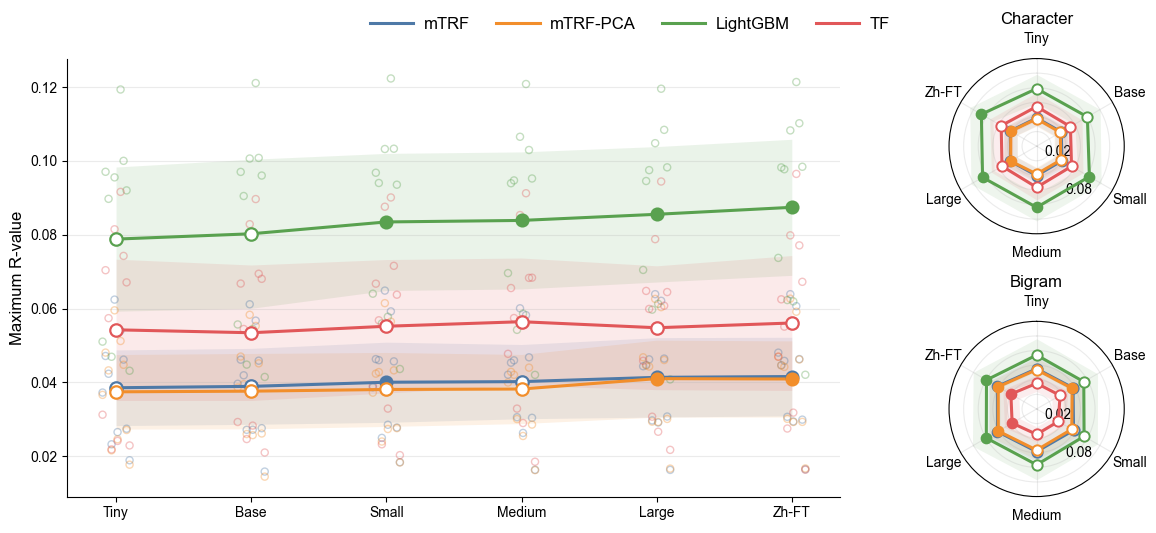

In [ ]:
# -------------------------
# Read the results
# -------------------------
df_char = {"method": list(), "model": list(), "sid": list(), "R": list()}
for method in METHODS:
    for sub in SUBS:
        for model in MODELS:
            r = FUNC_HANDLE(np.load(f"./results/{method}_iterate-model_sub/char-level/{sub}/whisper-{model}_r-obs.npy"))
            df_char["method"].append(method)
            df_char["model"].append(model)
            df_char["sid"].append(sub)
            df_char["R"].append(r)
df_char = pd.DataFrame(df_char)

df_word = {"method": list(), "model": list(), "sid": list(), "R": list()}
for method in METHODS:
    for sub in SUBS:
        for model in MODELS:
            r = FUNC_HANDLE(np.load(f"./results/{method}_iterate-model_sub/word-level/{sub}/whisper-{model}_r-obs.npy"))
            df_word["method"].append(method)
            df_word["model"].append(model)
            df_word["sid"].append(sub)
            df_word["R"].append(r)
df_word = pd.DataFrame(df_word)

# -------------------------
# Build one shared legend for the whole figure
# -------------------------
legend_handles = [
    Line2D([0], [0], color=COLOR_MAP[m], lw=2.2, label=m)
    for m in METHODS
]

# -------------------------
# Visualize the results
# -------------------------
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[2, 1], wspace=0.005, hspace=0.5)

ax_line = fig.add_subplot(gs[:, 0])
ax_radar1 = fig.add_subplot(gs[0, 1], polar=True)
ax_radar2 = fig.add_subplot(gs[1, 1], polar=True)

plot_line(ax_line, df_char, title=None)
plot_radar(ax_radar1, df_char, title="Character")
plot_radar(ax_radar2, df_word, title="Bigram")

ax_line.set_ylabel("Maximum R-value")

fig.legend(
    handles=legend_handles,
    labels=[h.get_label() for h in legend_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=len(METHODS),
    frameon=False,
    handlelength=2.6,
    columnspacing=1.6,
    handletextpad=0.6,
    fontsize=12
)

fig.subplots_adjust(top=0.84)

plt.show()